# Projeto: Análise de Churn para Empresa de Assinatura
## 1. Setup e Importações
## 2. Coleta e Carregamento dos Dados
## 3. Análise Exploratória (EDA)
## 4. Limpeza e Tratamento
## 5. Feature Engineering
## 6. Métricas e Cálculo do Churn
## 7. Exportação para Dashboard (Metabase/Tableau)
## 8. Insights de Negócio

Célula 1 - Importações

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

Célula 2 - Carregar dados

In [18]:
import pandas as pd

# Caminho relativo: sai de /notebooks/ e entra em /dados/
df = pd.read_csv('../dados/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Célula 3 - Análise inicial

In [19]:
# Informações gerais
df.info()

# Verificar valores nulos
df.isnull().sum()

# Estatísticas básicas
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Célula 4 - Tratamento da coluna TotalCharges (problema comum neste dataset)

In [20]:
# A coluna TotalCharges vem como string por causa de espaços
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Verificar nulos após conversão
print(f"Registros com TotalCharges nulo: {df['TotalCharges'].isnull().sum()}")

# Remover essas linhas (são poucas)
df = df.dropna(subset=['TotalCharges'])

# Confirmar
df.info()

Registros com TotalCharges nulo: 11
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032

Célula 5 - Verificar dados duplicados

In [21]:
# Verificar customerID duplicado
print(f"Clientes únicos: {df['customerID'].nunique()}")
print(f"Total linhas: {len(df)}")

# Se houver duplicatas, remover
df = df.drop_duplicates(subset=['customerID'])

Clientes únicos: 7032
Total linhas: 7032


Célula 6 - Feature Engineering (criar novas colunas)

In [22]:
# Criar grupos de tenure (tempo como cliente)
bins = [0, 6, 12, 24, 72]
labels = ['0-6 meses', '7-12 meses', '13-24 meses', '25+ meses']
df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)

# Criar faixas de mensalidade
bins_mensalidade = [0, 30, 50, 80, 120]
labels_mensalidade = ['Baixo (<30)', 'Médio (30-50)', 'Alto (50-80)', 'Premium (>80)']
df['MonthlyGroup'] = pd.cut(df['MonthlyCharges'], bins=bins_mensalidade, labels=labels_mensalidade)

# Converter Churn para numérico
df['Churn_Num'] = df['Churn'].map({'Yes': 1, 'No': 0})

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,MonthlyGroup,Churn_Num
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-6 meses,Baixo (<30),0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25+ meses,Alto (50-80),0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-6 meses,Alto (50-80),1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25+ meses,Médio (30-50),0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-6 meses,Alto (50-80),1


Célula 7 - Calcular métricas de Churn

In [23]:
# Taxa de churn geral
churn_rate = df['Churn_Num'].mean()
print(f"Taxa de Churn Geral: {churn_rate:.1%}")

# Churn por tipo de contrato
churn_by_contract = df.groupby('Contract')['Churn_Num'].agg(['mean', 'count'])
churn_by_contract['mean'] = churn_by_contract['mean'].round(4)
churn_by_contract = churn_by_contract.sort_values('mean', ascending=False)
churn_by_contract

Taxa de Churn Geral: 26.6%


,mean,count
Contract,,
Month-to-month,0.4271,3875
One year,0.1128,1472
Two year,0.0285,1685


Célula 8 - Churn por forma de pagamento

In [24]:
churn_by_payment = df.groupby('PaymentMethod')['Churn_Num'].mean().sort_values(ascending=False)
churn_by_payment = (churn_by_payment * 100).round(1)
print(churn_by_payment)

PaymentMethod
Electronic check             45.3
Mailed check                 19.2
Bank transfer (automatic)    16.7
Credit card (automatic)      15.3
Name: Churn_Num, dtype: float64


Célula 9 - Churn por tempo de uso

In [25]:
churn_by_tenure = df.groupby('TenureGroup')['Churn_Num'].mean().sort_values(ascending=False)
churn_by_tenure = (churn_by_tenure * 100).round(1)
print(churn_by_tenure)

TenureGroup
0-6 meses      54.7
7-12 meses     36.5
13-24 meses    29.5
25+ meses      15.6
Name: Churn_Num, dtype: float64


Célula 10 - Visualizações (para seu notebook)

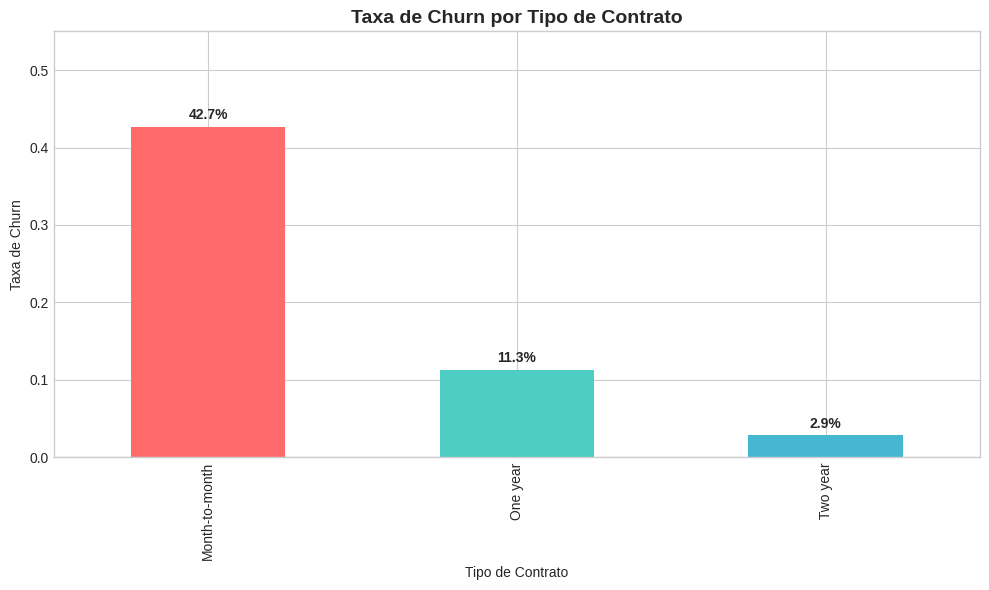

In [27]:
# Gráfico 1: Churn por tipo de contrato
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
churn_by_contract['mean'].plot(kind='bar', color=colors, ax=ax)
ax.set_title('Taxa de Churn por Tipo de Contrato', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Contrato')
ax.set_ylabel('Taxa de Churn')
ax.set_ylim(0, 0.55)
for i, v in enumerate(churn_by_contract['mean']):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../image/churn_by_contract.png', dpi=150)
plt.show()

Célula 11 - Matriz de correlação

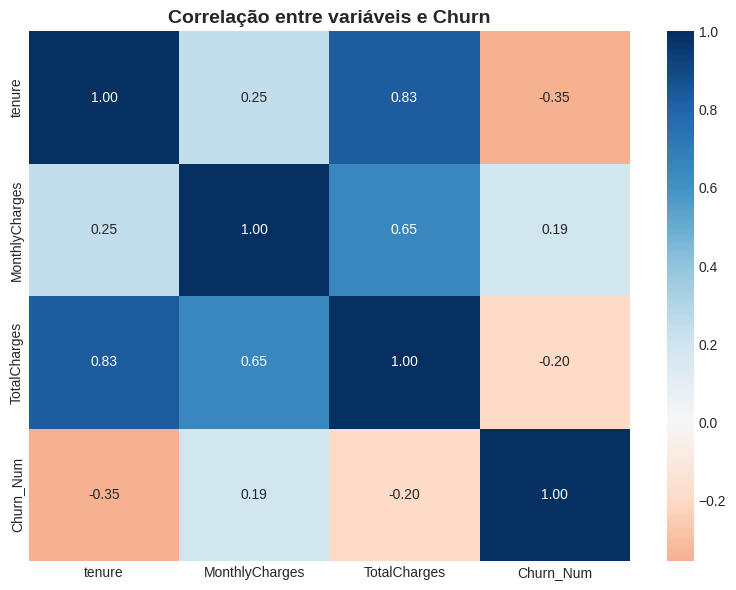

In [28]:
# Selecionar colunas numéricas
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Num']
corr_matrix = df[numeric_cols].corr()

# Plotar heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title('Correlação entre variáveis e Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../image/correlation_matrix.png', dpi=150)
plt.show()

Célula 12 - Exportar dados tratados

In [29]:
# Salvar dataset limpo para usar no Metabase/Tableau
df_clean = df.drop(columns=['Churn_Num'])  # Remove coluna auxiliar
df_clean.to_csv('../dados/telco_churn_cleaned.csv', index=False)

print("Arquivo exportado: telco_churn_cleaned.csv")
print(f"Shape final: {df_clean.shape}")

Arquivo exportado: telco_churn_cleaned.csv
Shape final: (7032, 23)


Célula 13 - Resumo dos insights (markdown)

## INSIGHTS ENCONTRADOS

1. **Contrato mensal é o maior vilão** - Taxa de churn de ~42%, enquanto contratos anuais têm apenas ~11%

2. **Forma de pagamento importa** - Clientes que pagam com boleto cancelam 2x mais que débito automático

3. **Primeiros meses são críticos** - 45% dos cancelamentos acontecem nos primeiros 6 meses

4. **Clientes com alta mensalidade cancelam menos** - Quem paga mais tende a ficar mais tempo

## RECOMENDAÇÕES

✅ Criar programa de onboarding para primeiros 6 meses  
✅ Oferecer desconto para migração de contrato mensal para anual  
✅ Incentivar débito automático (cashback ou desconto)  
✅ Identificar clientes com perfil de risco (boleto + contrato mensal + <6 meses)